[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter13_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 13: Machine learning

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Bias and variance; validation for time series: walk-forward, purging, leakage.
- Ridge and lasso; regression trees, random forest, gradient boosting; neural networks and the SFE Quantlets SFEnnarch and SFEnnjpyusd.
- Applications: weekly realised volatility (HAR against machine learning), the sign of daily returns, VaR 1% by quantile regression; data snooping and the deflated Sharpe ratio; the case study of Gu, Kelly and Xiu (2020).
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 19; James et al. (2023), *An Introduction to Statistical Learning with Applications in Python*; Corsi (2009); Breiman (2001); Friedman (2001); Bailey and López de Prado (2014); Gu, Kelly and Xiu (2020).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily variance proxy (Chapter 8): $v_t = o_t^2 + \tfrac12(u_t - d_t)^2 - (2\ln 2 - 1)c_t^2$ with $o_t$ the overnight log return and $u_t, d_t, c_t$ the log high, low and close relative to the open (all in %).
- Volatility target: $y_t = \ln(\frac15\sum_{j=1}^5 v_{t+j})$; HAR features: $\ln v_t$ and the logs of the 5-day and 22-day means of $v$.
- Walk-forward: one test year at a time, an expanding training window, the last $h$ training rows purged.
- VaR 1% $= -\hat q_{0.01}$: the loss exceeded with probability 1%, a positive number.

In [6]:
from matplotlib.patches import Rectangle, Circle
from sklearn.cluster import KMeans
from sklearn.ensemble import (GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier,
                              RandomForestRegressor)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (Lasso, LassoCV, LinearRegression, LogisticRegression, QuantileRegressor, Ridge,
                                  lasso_path)
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from arch import arch_model
TABLE_DIR = '.'
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'gbpusd': 'GBP/USD', 'usdjpy': 'USD/JPY'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2006-01-01', 'btc': None}
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
MCOL = {'HAR': '#1A3A6E', 'Lasso': '#17A2B8', 'RF': '#2E7D32', 'GB': '#E67E22', 'MLP': '#8E44AD', 'Mean': '#B5853F', 'Logit': '#1A3A6E', 'QR': '#2E7D32', 'QGB': '#E67E22', 'HS': '#B5853F', 'GARCH-t': '#CD0000'}
H = 5
OOS = {'sp500': '2013-01-01', 'dax': '2012-01-01', 'btc': '2018-01-01', 'bet': '2008-01-01', 'tlv': '2014-01-01', 'snp': '2014-01-01'}
OOS_SIGN = {'sp500': '2008-01-01', 'dax': '2008-01-01', 'bet': '2008-01-01', 'btc': '2018-01-01', 'tlv': '2014-01-01', 'snp': '2014-01-01'}
HAR = ['d', 'w', 'm']
EXT = ['d', 'w', 'm', 'd1', 'd2', 'd3', 'd4', 'q', 'r', 'r_neg', 'abs_r']
FEAT_LABEL = {'d': 'log RV day', 'w': 'log RV week', 'm': 'log RV month', 'd1': 'log RV lag 1', 'd2': 'log RV lag 2', 'd3': 'log RV lag 3', 'd4': 'log RV lag 4', 'q': 'log RV quarter', 'r': 'return', 'r_neg': 'negative return', 'abs_r': 'absolute return'}
FEAT_COL = {'d': '#1A3A6E', 'w': '#CD0000', 'm': '#2E7D32', 'd1': '#17A2B8', 'd2': '#8E44AD', 'd3': '#E67E22', 'd4': '#B5853F', 'q': '#DC3545', 'r': '#6B8E23', 'r_neg': '#C71585', 'abs_r': '#00008B'}
SIGN_FEATS = ['r0', 'r1', 'r2', 'r3', 'r4', 'm5', 'm21', 'm63', 'v21', 'v63']
QV_FEATS = ['sd', 'sw', 'sm', 'r']
ALPHA_VAR = 0.01
HS_WINDOW = 500
SEED = 2026
N_TREES = 300
EULER = 0.5772156649
GKX_MODELS = ['OLS-3+H', 'PLS', 'PCR', 'ENet+H', 'GLM+H', 'RF', 'GBRT+H', 'NN1', 'NN2', 'NN3', 'NN4', 'NN5']
GKX_R2 = [0.16, 0.27, 0.26, 0.11, 0.19, 0.33, 0.34, 0.33, 0.39, 0.4, 0.39, 0.36]
GKX_R2_TOP = [0.31, -0.14, 0.06, 0.25, 0.14, 0.63, 0.52, 0.49, 0.62, 0.7, 0.67, 0.64]
GKX_SR = [0.61, 0.72, 0.88, 0.39, 0.76, 0.98, 0.81, 1.17, 1.16, 1.2, 1.35, 1.15]


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def fx_close(symbol, start='2000-01-01'):
    """Close of an exchange rate or yield from the course data: weekdays only, unchanged (holiday) closes dropped."""
    s = pd.to_numeric(read_market(symbol)['close'], errors='coerce').dropna().loc[start:END]
    s = s[s.index.dayofweek < 5]
    return s[s.diff() != 0]


def ohlc(k, start=None):
    """Open, high, low and close prices (indices and crypto as quoted). Weekend quotes and days without trading are
    dropped, except for crypto; inconsistent rows (high below open or close, low above them) are dropped."""
    symbol, _, group, field, start0 = SERIES[k]
    t = read_market(symbol).loc[(start or OHLC_START.get(k) or start0):END]
    t = t[['open', 'high', 'low', 'close']].apply(pd.to_numeric, errors='coerce').dropna()
    t = t[(t > 0).all(axis=1)]
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
        t = t[~((t['close'].diff() == 0) & (t['high'] == t['low']))]
    return t[(t['high'] >= t[['open', 'close']].max(axis=1)) & (t['low'] <= t[['open', 'close']].min(axis=1))]


def daily_variance(k):
    """Daily variance proxy of Chapter 8 (%^2): overnight return squared plus the Garman-Klass term,
    v_t = o_t^2 + 0.5 (u - d)^2 - (2 ln 2 - 1) c^2, with o = ln(O_t/C_t-1), u = ln(H/O), d = ln(L/O), c = ln(C/O)."""
    t = ohlc(k)
    lo, lh, ll, lc = (100 * np.log(t[c]) for c in ['open', 'high', 'low', 'close'])
    o, u, d, c = lo - lc.shift(), lh - lo, ll - lo, lc - lo
    v = (o ** 2 + 0.5 * (u - d) ** 2 - (2 * np.log(2) - 1) * c ** 2).dropna()
    r = (lc - lc.shift()).dropna()
    return v.clip(lower=0.01 * v.median()), r


def rv_frame(k, h=H):
    """Features at the close of day t and the target: y = log of the mean variance proxy over days t+1..t+h.
    HAR features: d = log v_t, w = log mean(v_t-4..v_t), m = log mean(v_t-21..v_t); extended: lags 1-4 of d,
    q = log mean over 66 days, the return r_t, its negative part and its absolute value."""
    v, r = daily_variance(k)
    X = pd.DataFrame({'d': np.log(v), 'w': np.log(v.rolling(5).mean()), 'm': np.log(v.rolling(22).mean()),
                      'q': np.log(v.rolling(66).mean())})
    for j in range(1, 5):
        X[f'd{j}'] = X['d'].shift(j)
    X['r'] = r
    X['r_neg'] = r.clip(upper=0)
    X['abs_r'] = r.abs()
    fut = sum(v.shift(-j) for j in range(1, h + 1)) / h
    X['rv'] = fut                       # target in levels (%^2 per day), for QLIKE
    X['y'] = np.log(fut)                # target in logs
    return X.dropna()

## 1. Bias and variance of regression trees

- 300 simulated training samples of $y = \sin(2\pi x) + \varepsilon$; squared bias, variance and test error against the depth.

In [7]:
def true_f(x):
    """The regression function of the simulation."""
    return np.sin(2 * np.pi * x)


def bias_variance(depths=range(1, 11), n=80, sigma=0.3, B=300, seed=SEED):
    """Regression trees of depth 1..10 on B simulated training sets y = sin(2 pi x) + e, e ~ N(0, sigma^2): squared bias,
    variance and expected test error (bias^2 + variance + sigma^2) on a grid, and the average training error."""
    rng = np.random.default_rng(seed)
    grid = np.linspace(0.01, 0.99, 200)
    out = {}
    for dep in depths:
        P, tr = np.empty((B, len(grid))), []
        for b in range(B):
            x = rng.uniform(0, 1, n)
            y = true_f(x) + rng.normal(0, sigma, n)
            m = DecisionTreeRegressor(max_depth=dep, random_state=0).fit(x[:, None], y)
            P[b] = m.predict(grid[:, None])
            tr.append(np.mean((m.predict(x[:, None]) - y) ** 2))
        bias2 = float(np.mean((P.mean(0) - true_f(grid)) ** 2))
        var = float(np.mean(P.var(0)))
        out[int(dep)] = {'bias2': bias2, 'var': var, 'test': bias2 + var + sigma ** 2, 'train': float(np.mean(tr))}
    return out


def fig_bias_variance(bv=None, n=80, sigma=0.3, seed=SEED, save=True):
    """Left: one simulated sample with trees of depth 1, 3 and 10; right: bias^2, variance, test and training error."""
    bv = bv or bias_variance()
    rng = np.random.default_rng(seed + 1)
    x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, sigma, n)
    grid = np.linspace(0, 1, 400)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    ax[0].scatter(x, y, s=14, color=st.MainBlue, alpha=0.6, label='training data')
    ax[0].plot(grid, true_f(grid), color='black', lw=1.6, label='true function')
    for dep, col in [(1, st.Amber), (3, st.Forest), (10, st.IDAred)]:
        m = DecisionTreeRegressor(max_depth=dep, random_state=0).fit(x[:, None], y)
        ax[0].plot(grid, m.predict(grid[:, None]), color=col, lw=1.6, label=f'tree of depth {dep}')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    d = sorted(bv)
    ax[1].plot(d, [bv[k]['bias2'] for k in d], color=st.Amber, marker='o', label='squared bias')
    ax[1].plot(d, [bv[k]['var'] for k in d], color=st.Purple, marker='o', label='variance')
    ax[1].plot(d, [bv[k]['test'] for k in d], color=st.IDAred, marker='o', lw=2, label='expected test error')
    ax[1].plot(d, [bv[k]['train'] for k in d], color=st.Forest, marker='o', ls='--', label='training error')
    ax[1].axhline(sigma ** 2, color=st.MainBlue, ls=':', lw=1.2, label='noise variance')
    ax[1].set_xlabel('tree depth (complexity)')
    ax[1].set_ylabel('mean squared error')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_bias_variance')
    best = min(bv, key=lambda k: bv[k]['test'])
    return {'best_depth': int(best), 'sigma2': sigma ** 2, 'n': n,
            **{f'd{k}': bv[k] for k in (1, 3, best, 10)}}

{'best_depth': 3,
 'sigma2': 0.09,
 'n': 80,
 'd1': {'bias2': 0.06961967724978463,
  'var': 0.030855744380230917,
  'test': 0.19047542163001555,
  'train': 0.17246518495996555},
 'd3': {'bias2': 0.003886419963225618,
  'var': 0.037737949789936866,
  'test': 0.1316243697531625,
  'train': 0.07455440006978596},
 'd10': {'bias2': 0.00025089607175832727,
  'var': 0.09024067853932843,
  'test': 0.18049157461108675,
  'train': 0.001995187655416355}}

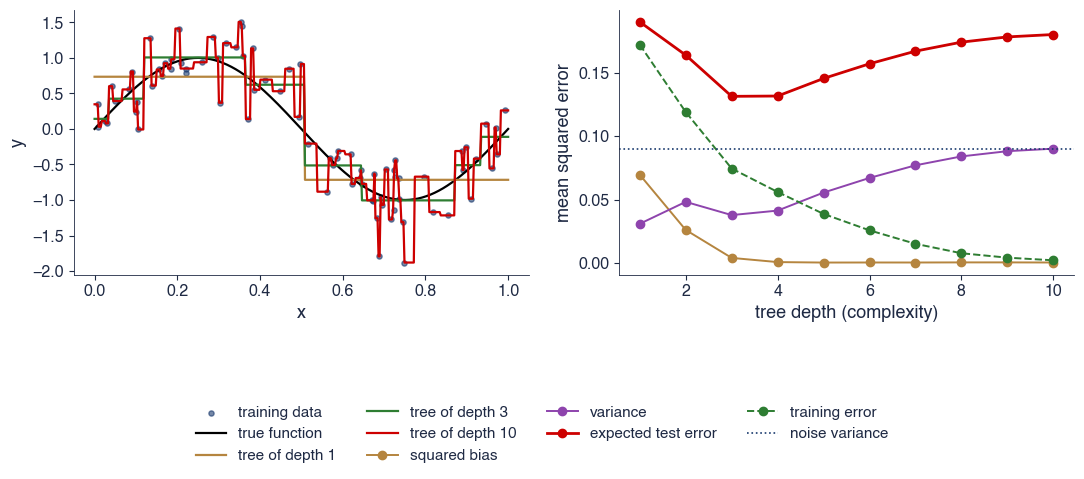

In [8]:
fig_bias_variance(save=False)

## 2. Validation for time series

- Random K-fold, walk-forward and purged K-fold; a random forest for the next 21-day return: shuffled folds leak through overlapping targets.

In [9]:
def fig_cv_schemes(n=60, k=5, h=3, emb=2, save=True):
    """Diagram of three validation schemes on n ordered observations: random K-fold, walk-forward (expanding) and
    purged K-fold with an embargo (h observations purged before the test block, emb observations after it)."""
    fig, ax = plt.subplots(figsize=(10.5, 4.6))
    rng = np.random.default_rng(3)
    perm = rng.permutation(n)
    folds = np.array_split(perm, k)
    colors = {'train': st.MainBlue, 'test': st.IDAred, 'purged': st.Amber, 'embargo': st.Orange, 'unused': 'white'}
    rows = []
    for i in range(k):                                   # random K-fold
        lab = np.array(['train'] * n, dtype=object)
        lab[folds[i]] = 'test'
        rows.append((f'random K-fold, fold {i + 1}', lab))
    size = n // (k + 1)
    for i in range(k):                                   # walk-forward, expanding window
        lab = np.array(['unused'] * n, dtype=object)
        lab[:size * (i + 1)] = 'train'
        lab[size * (i + 1):size * (i + 2)] = 'test'
        rows.append((f'walk-forward, step {i + 1}', lab))
    block = n // k
    for i in range(k):                                   # purged K-fold with embargo
        lab = np.array(['train'] * n, dtype=object)
        a, b = i * block, (i + 1) * block
        lab[a:b] = 'test'
        lab[max(0, a - h):a] = 'purged'
        lab[b:min(n, b + emb)] = 'embargo'
        rows.append((f'purged K-fold, fold {i + 1}', lab))
    for j, (name, lab) in enumerate(rows):
        yy = len(rows) - j - 1 + (0 if j < 5 else (-0.5 if j < 10 else -1.0))
        for t in range(n):
            ax.add_patch(Rectangle((t, yy), 0.95, 0.8, facecolor=colors[lab[t]],
                                   edgecolor=st.MainBlue if lab[t] == 'unused' else 'none', lw=0.3))
        ax.text(-1, yy + 0.4, name, ha='right', va='center', fontsize=9.5, color='black')
    ax.set_xlim(-22, n + 1)
    ax.set_ylim(-1.3, len(rows) + 0.2)
    ax.axis('off')
    ax.annotate('', xy=(n, -1.1), xytext=(0, -1.1), arrowprops=dict(arrowstyle='->', color='black'))
    ax.text(n / 2, -1.25, 'time', ha='center', va='top', fontsize=10, color='black')
    handles = [Rectangle((0, 0), 1, 1, facecolor=colors[c], edgecolor=st.MainBlue if c == 'unused' else 'none')
               for c in ['train', 'test', 'purged', 'embargo', 'unused']]
    fig.legend(handles, ['training', 'test', 'purged (target overlaps the test block)', 'embargo', 'not used yet'],
               loc='upper center', bbox_to_anchor=(0.5, 0.04), ncol=5, frameon=False, fontsize=9.5)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_cv_schemes')


def leakage_frame(r, h=21):
    """Features from past returns and a target that overlaps from one day to the next: the sum of the next h returns."""
    X = pd.DataFrame({'m5': r.rolling(5).sum(), 'm21': r.rolling(21).sum(), 'm63': r.rolling(63).sum(),
                      'v21': r.rolling(21).std(), 'v63': r.rolling(63).std()})
    X['y'] = sum(r.shift(-j) for j in range(1, h + 1))
    return X.dropna()


def oos_r2(y, yhat, ybar):
    """Out-of-sample R^2 against a benchmark forecast ybar: 1 - sum (y - yhat)^2 / sum (y - ybar)^2."""
    y, yhat, ybar = (np.asarray(a, float) for a in (y, yhat, ybar))
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - ybar) ** 2))


def cv_r2(X, splitter, feats=('m5', 'm21', 'm63', 'v21', 'v63'), seed=SEED):
    """Pooled out-of-sample R^2 of a random forest under a cross-validation scheme (benchmark: the training mean)."""
    y, yh, yb = [], [], []
    for tr, te in splitter.split(X):
        m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.6, n_jobs=-1, random_state=seed)
        m.fit(X.iloc[tr][list(feats)], X['y'].iloc[tr])
        y += list(X['y'].iloc[te])
        yh += list(m.predict(X.iloc[te][list(feats)]))
        yb += [X['y'].iloc[tr].mean()] * len(te)
    return oos_r2(y, yh, yb)


def leakage_experiment(h=21, n=4000, seed=SEED):
    """Random 5-fold, walk-forward and purged walk-forward R^2 for the next-h-day return: a simulated random walk
    (nothing to predict) and the S&P 500 since 2000."""
    rng = np.random.default_rng(seed)
    sim = pd.Series(rng.normal(0, 1, n), index=pd.bdate_range('2000-01-03', periods=n))
    out = {}
    for lab, r in [('sim', sim), ('sp500', returns('sp500'))]:
        X = leakage_frame(r, h)
        out[lab] = {'n': int(len(X)),
                    'kfold': cv_r2(X, KFold(5, shuffle=True, random_state=seed)),
                    'wf': cv_r2(X, TimeSeriesSplit(5)),
                    'purged': cv_r2(X, TimeSeriesSplit(5, gap=h))}
    return out


def fig_leakage(L=None, save=True):
    """Bar chart of the out-of-sample R^2 under the three schemes."""
    L = L or leakage_experiment()
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    labs = [('kfold', 'random 5-fold (shuffled)', st.IDAred), ('wf', 'walk-forward', st.MainBlue),
            ('purged', 'walk-forward, purged (gap of 21 days)', st.Forest)]
    xs = np.arange(2)
    for i, (key, lab, col) in enumerate(labs):
        vals = [100 * L[s][key] for s in ('sim', 'sp500')]
        b = ax.bar(xs + (i - 1) * 0.26, vals, width=0.25, color=col, label=lab)
        for rect, v in zip(b, vals):
            ax.text(rect.get_x() + rect.get_width() / 2, v + (1 if v >= 0 else -1), f'{v:.1f}',
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=10, color='black')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(['simulated random walk\n(nothing to predict)', 'S&P 500, 2000-2026'])
    ax.set_ylabel('out-of-sample $R^2$ (%)')
    lo = min(100 * L[s][k] for s in ('sim', 'sp500') for k in ('kfold', 'wf', 'purged'))
    ax.set_ylim(min(lo - 6, -10), max(100 * L[s]['kfold'] for s in ('sim', 'sp500')) + 8)
    st.legend_outside_bottom(ax, ncol=3, y=-0.25)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_leakage')
    return L

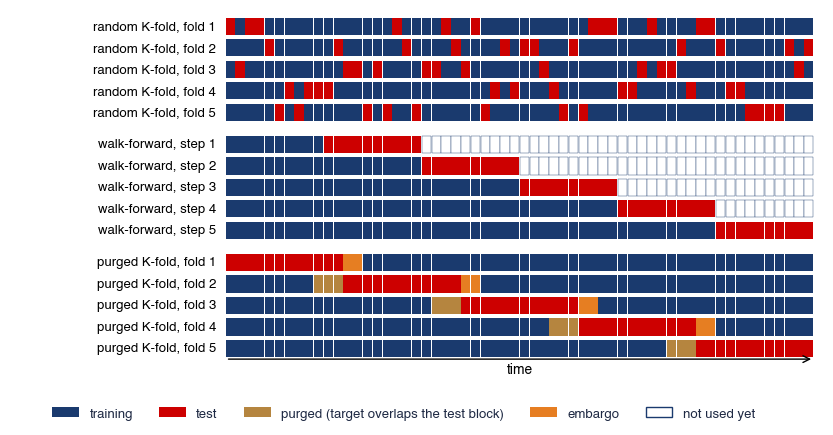

In [10]:
fig_cv_schemes(save=False)

{'sim': {'n': 3917,
  'kfold': 0.3451351840759278,
  'wf': -0.2611891635010404,
  'purged': -0.268739728294612},
 'sp500': {'n': 6631,
  'kfold': 0.36914566394197224,
  'wf': -0.37989260958288806,
  'purged': -0.38755995015707967}}

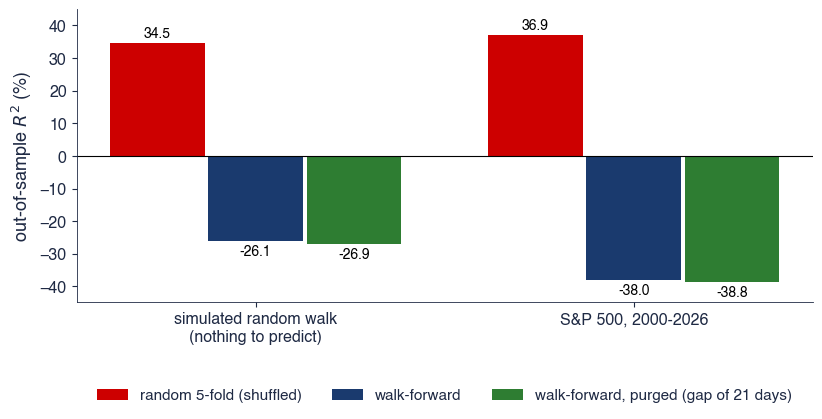

In [11]:
fig_leakage(save=False)

## 3. Ridge and lasso

- Coefficient paths of 11 volatility features of the S&P 500, 2008–2012.

In [12]:
def shrinkage_paths(k='sp500', end='2012-12-31'):
    """Ridge and lasso coefficient paths of the extended volatility features (standardised), estimated on the data
    before the first out-of-sample year; the lasso penalty chosen by walk-forward cross-validation (5 splits, a gap
    of H days)."""
    X = rv_frame(k).loc[:end]
    Z = StandardScaler().fit_transform(X[EXT])
    y = X['y'].values - X['y'].mean()
    lam_l = np.logspace(-4, 0, 60)
    _, coefs, _ = lasso_path(Z, y, alphas=lam_l)
    lam_r = np.logspace(-2, 5, 60)
    ridge = np.array([Ridge(alpha=a).fit(Z, y).coef_ for a in lam_r])
    cv = LassoCV(alphas=lam_l, cv=TimeSeriesSplit(5, gap=H)).fit(Z, y)
    ols = LinearRegression().fit(Z, y).coef_
    return {'lam_l': lam_l, 'lasso': coefs.T, 'lam_r': lam_r, 'ridge': ridge, 'cv_alpha': float(cv.alpha_),
            'cv_coef': dict(zip(EXT, cv.coef_.tolist())), 'ols': dict(zip(EXT, ols.tolist())), 'n': int(len(X)),
            'nonzero': int(np.sum(np.abs(cv.coef_) > 1e-10))}


def fig_shrinkage(S=None, save=True):
    """Coefficient paths: ridge (left) and lasso (right) against the penalty; dashed: the lasso penalty chosen by CV."""
    S = S or shrinkage_paths()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))
    for j, f in enumerate(EXT):
        ax[0].plot(S['lam_r'], S['ridge'][:, j], color=FEAT_COL[f], lw=1.4, label=FEAT_LABEL[f])
        ax[1].plot(S['lam_l'], S['lasso'][:, j], color=FEAT_COL[f], lw=1.4)
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    ax[1].axvline(S['cv_alpha'], color='black', ls='--', lw=1)
    ax[1].text(S['cv_alpha'] * 1.15, ax[1].get_ylim()[1] * 0.9, 'chosen by\nwalk-forward CV', fontsize=9.5,
               color='black', va='top')
    ax[0].set_xlabel(r'ridge penalty $\lambda$ (log scale)')
    ax[1].set_xlabel(r'lasso penalty $\lambda$ (log scale)')
    ax[0].set_ylabel('coefficient (standardised features)')
    for a in ax:
        a.axhline(0, color='black', lw=0.6)
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.17, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_shrinkage')
    return {'cv_alpha': S['cv_alpha'], 'cv_coef': S['cv_coef'], 'ols': S['ols'], 'n': S['n'], 'nonzero': S['nonzero']}

{'cv_alpha': 0.007912342618981327,
 'cv_coef': {'d': 0.12571648311374464,
  'w': 0.28272253150660337,
  'm': 0.19881854765610407,
  'd1': 0.11754856989133855,
  'd2': 0.058776665853824364,
  'd3': 0.028947422141223644,
  'd4': 0.027083901176537726,
  'q': 0.05393999761966705,
  'r': -0.014435758379694304,
  'r_neg': -0.11167951283853206,
  'abs_r': 0.0},
 'ols': {'d': 0.1469590432084472,
  'w': 0.19937808323229456,
  'm': 0.19728777588703666,
  'd1': 0.13933962312808668,
  'd2': 0.08082140161943219,
  'd3': 0.05087980140382699,
  'd4': 0.048602852194572596,
  'q': 0.056520127733841845,
  'r': -0.06082208078728928,
  'r_neg': -0.06151341161317757,
  'abs_r': 0.026453528816056893},
 'n': 1193,
 'nonzero': 10}

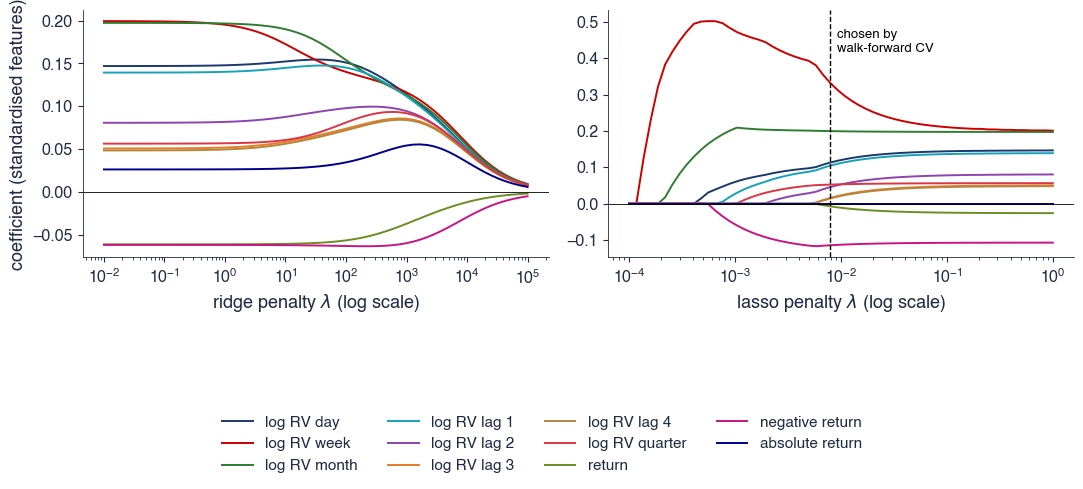

In [13]:
fig_shrinkage(save=False)

## 4. Trees, random forest and gradient boosting

In [14]:
def fig_tree(k='sp500', end='2012-12-31', save=True):
    """A regression tree of depth 2 for the weekly log realised variance, on the three HAR features."""
    X = rv_frame(k).loc[:end]
    m = DecisionTreeRegressor(max_depth=2, min_samples_leaf=50, random_state=0).fit(X[HAR], X['y'])
    fig, ax = plt.subplots(figsize=(10, 4.2))
    plot_tree(m, feature_names=[FEAT_LABEL[f] for f in HAR], filled=False, impurity=False, rounded=True, precision=2,
              fontsize=10, ax=ax)
    for t in ax.texts:                       # white boxes drawn above the arrows of the lower levels
        t.set_color('black')
        if t.get_bbox_patch() is not None:
            t.get_bbox_patch().set_facecolor('white')
        t.set_zorder(10 + 10 * t.get_position()[1])
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_tree')
    tr = m.tree_
    return {'n': int(len(X)), 'root_feature': FEAT_LABEL[HAR[tr.feature[0]]], 'root_threshold': float(tr.threshold[0]),
            'root_vol': float(np.sqrt(252 * np.exp(tr.threshold[0]))),
            'leaves': [float(v) for v, f in zip(tr.value.ravel(), tr.feature) if f < 0],
            'leaf_n': [int(c) for c, f in zip(tr.n_node_samples, tr.feature) if f < 0], 'mean_y': float(X['y'].mean())}


def ensemble_curves(k='sp500', split='2018-12-31', end='2022-12-31', seed=SEED):
    """Validation MSE (2019-2022) of a single tree and a random forest for depth 1..14, and of gradient boosting against
    the number of trees for three learning rates (training: the data up to 2018, purged)."""
    X = rv_frame(k)
    tr, va = X.loc[:split].iloc[:-H], X.loc[split:end].iloc[1:]
    out = {'depth': list(range(1, 15)), 'tree': [], 'rf': []}
    for dep in out['depth']:
        t = DecisionTreeRegressor(max_depth=dep, random_state=0).fit(tr[EXT], tr['y'])
        f = RandomForestRegressor(n_estimators=200, max_depth=dep, max_features=0.5, n_jobs=-1, random_state=seed)
        f.fit(tr[EXT], tr['y'])
        out['tree'].append(float(np.mean((t.predict(va[EXT]) - va['y']) ** 2)))
        out['rf'].append(float(np.mean((f.predict(va[EXT]) - va['y']) ** 2)))
    out['gb'] = {}
    for lr in (0.3, 0.1, 0.03):
        g = GradientBoostingRegressor(n_estimators=500, learning_rate=lr, max_depth=3, subsample=0.8, random_state=seed)
        g.fit(tr[EXT], tr['y'])
        out['gb'][lr] = {'val': [float(np.mean((p - va['y']) ** 2)) for p in g.staged_predict(va[EXT])],
                         'train': [float(np.mean((p - tr['y']) ** 2)) for p in g.staged_predict(tr[EXT])]}
    har = LinearRegression().fit(tr[HAR], tr['y'])
    out['har'] = float(np.mean((har.predict(va[HAR]) - va['y']) ** 2))
    out['n_train'], out['n_val'] = int(len(tr)), int(len(va))
    return out


def fig_ensembles(E=None, save=True):
    """Left: validation MSE against depth, single tree and random forest; right: gradient boosting against the number
    of trees (solid: validation, dashed: training)."""
    E = E or ensemble_curves()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    ax[0].plot(E['depth'], E['tree'], color=st.Amber, marker='o', label='single tree')
    ax[0].plot(E['depth'], E['rf'], color=st.Forest, marker='o', label='random forest (200 trees)')
    for a in ax:
        a.axhline(E['har'], color=st.MainBlue, ls=':', lw=1.4, label='HAR regression' if a is ax[0] else None)
    ax[0].set_xlabel('maximum depth')
    ax[0].set_ylabel('validation MSE, log RV')
    cols = {0.3: st.IDAred, 0.1: st.Purple, 0.03: st.Orange}
    for lr, d in E['gb'].items():
        n = np.arange(1, len(d['val']) + 1)
        ax[1].plot(n, d['val'], color=cols[lr], lw=1.6, label=f'boosting, learning rate {lr}')
        ax[1].plot(n, d['train'], color=cols[lr], lw=1.0, ls='--')
    ax[1].set_xlabel('number of trees')
    ax[1].set_ylim(min(min(d['train']) for d in E['gb'].values()) * 0.9, max(E['tree']) * 1.05)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_ensembles')
    best = {lr: int(np.argmin(d['val']) + 1) for lr, d in E['gb'].items()}
    return {'har': E['har'], 'tree_best': float(min(E['tree'])), 'tree_best_depth': int(np.argmin(E['tree']) + 1),
            'rf_best': float(min(E['rf'])), 'rf_best_depth': int(np.argmin(E['rf']) + 1),
            'tree14': E['tree'][-1], 'rf14': E['rf'][-1],
            'gb_best': {str(lr): float(min(d['val'])) for lr, d in E['gb'].items()},
            'gb_best_n': {str(lr): best[lr] for lr in best}, 'gb_last': {str(lr): d['val'][-1] for lr, d in E['gb'].items()},
            'n_train': E['n_train'], 'n_val': E['n_val']}

{'n': 1193,
 'root_feature': 'log RV week',
 'root_threshold': 0.44203776121139526,
 'root_vol': 19.801019462130338,
 'leaves': [-0.9977229245332866,
  -0.28233400168896683,
  0.8220562131492399,
  1.8041123307320435],
 'leaf_n': [421, 513, 164, 95],
 'mean_y': -0.21682380864956757}

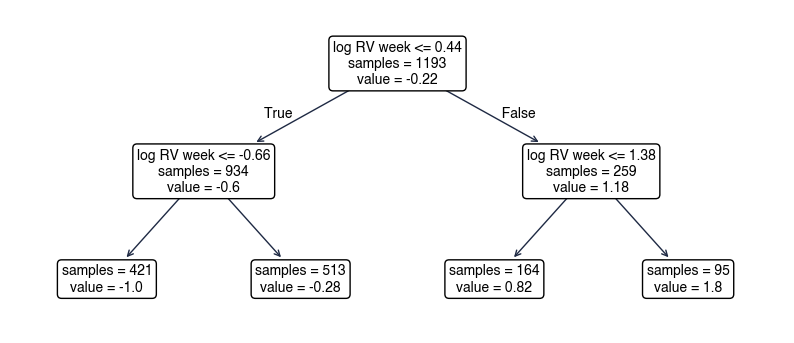

In [15]:
fig_tree(save=False)

{'har': 0.4871283936688631,
 'tree_best': 0.5182920346637024,
 'tree_best_depth': 5,
 'rf_best': 0.4580805661734813,
 'rf_best_depth': 8,
 'tree14': 0.8192939880965029,
 'rf14': 0.4651076858343144,
 'gb_best': {'0.3': 0.45667708204038415,
  '0.1': 0.4527720492541285,
  '0.03': 0.4509109036624352},
 'gb_best_n': {'0.3': 13, '0.1': 86, '0.03': 154},
 'gb_last': {'0.3': 0.5684498702079905,
  '0.1': 0.5002413131844717,
  '0.03': 0.4611437888729589},
 'n_train': 2698,
 'n_val': 1008}

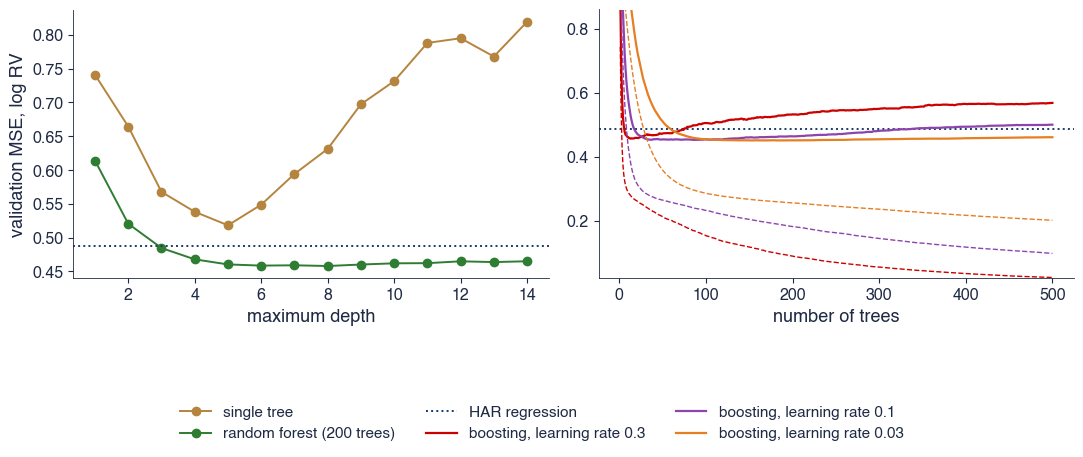

In [16]:
fig_ensembles(save=False)

## 5. Neural networks: an MLP, NN-ARCH (SFEnnarch) and the yen–dollar rate (SFEnnjpyusd)

- Radial basis function networks with 3 units, as in the SFE Quantlets; GARCH(1,1) and the random walk as benchmarks.

In [17]:
def fig_mlp(save=True):
    """Left: a multilayer perceptron with 3 inputs, 5 hidden neurons and one output; right: activation functions."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={'width_ratios': [1.15, 1]})
    layers = [['log RV day', 'log RV week', 'log RV month'], [''] * 5, ['forecast']]
    xs = [0.1, 0.5, 0.9]
    pos = []
    for x, lay in zip(xs, layers):
        ys = np.linspace(0.85, 0.15, len(lay)) if len(lay) > 1 else [0.5]
        pos.append([(x, y) for y in ys])
    for a, b in zip(pos[:-1], pos[1:]):
        for p in a:
            for q in b:
                ax[0].plot([p[0], q[0]], [p[1], q[1]], color=st.Teal, lw=0.8, zorder=1)
    for i, (lay, ps) in enumerate(zip(layers, pos)):
        col = [st.MainBlue, st.Forest, st.IDAred][i]
        for (x, y), lab in zip(ps, lay):
            ax[0].add_patch(Circle((x, y), 0.045, facecolor=col, edgecolor='black', zorder=2))
            if lab:
                ax[0].text(x + (-0.07 if i == 0 else 0.07), y, lab, ha='right' if i == 0 else 'left', va='center',
                           fontsize=10, color='black')
    ax[0].text(0.5, 0.97, 'hidden layer: $h_j = g(b_j + w_j^\\top x)$', ha='center', fontsize=10.5, color='black')
    ax[0].text(0.9, 0.36, 'output:\n$\\hat y = c + v^\\top h$', ha='center', va='top', fontsize=10.5, color='black')
    ax[0].set_xlim(-0.25, 1.2)
    ax[0].set_ylim(0, 1.02)
    ax[0].axis('off')
    z = np.linspace(-4, 4, 400)
    ax[1].plot(z, 1 / (1 + np.exp(-z)), color=st.MainBlue, lw=1.8, label='logistic $1/(1+e^{-z})$')
    ax[1].plot(z, np.tanh(z), color=st.IDAred, lw=1.8, label='tanh $z$')
    ax[1].plot(z, np.maximum(z, 0), color=st.Forest, lw=1.8, label='ReLU $\\max(0, z)$')
    ax[1].set_ylim(-1.2, 2.5)
    ax[1].axhline(0, color='black', lw=0.6)
    ax[1].set_xlabel('$z$')
    ax[1].set_ylabel('$g(z)$')
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.2)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_mlp')


class MLPEnsemble:
    """The average of several small MLPs (different random starting weights); inputs and target standardised.
    One hidden layer with 16 ReLU neurons, L2 penalty alpha, Adam optimiser, a fixed number of epochs."""

    def __init__(self, hidden=(16,), alpha=1e-2, n_models=5, epochs=200, seed=SEED):
        self.hidden, self.alpha, self.n_models, self.epochs, self.seed = hidden, alpha, n_models, epochs, seed

    def fit(self, X, y):
        self.sx = StandardScaler().fit(X)
        self.my, self.sy = float(np.mean(y)), float(np.std(y))
        Z, t = self.sx.transform(X), (np.asarray(y) - self.my) / self.sy
        self.models = [MLPRegressor(hidden_layer_sizes=self.hidden, alpha=self.alpha, max_iter=self.epochs,
                                    random_state=self.seed + i).fit(Z, t) for i in range(self.n_models)]
        return self

    def predict(self, X):
        Z = self.sx.transform(X)
        return self.my + self.sy * np.mean([m.predict(Z) for m in self.models], axis=0)


def rbf_fit(X, y, clusters=3, seed=SEED):
    """Radial basis function network as in SFEnnarch / SFEnnjpyusd: inputs scaled to [0, 1] (training range), cluster
    centres by k-means, width of unit c = sqrt(sum_k ||c_c - c_k||^2 / (clusters - 1)), Gaussian units
    exp(-(||x - c_j|| / s_j)^2), output weights and bias by least squares."""
    X = np.asarray(X, float)
    lo, hi = X.min(0), X.max(0)
    Z = (X - lo) / np.where(hi > lo, hi - lo, 1)
    km = KMeans(n_clusters=clusters, n_init=10, random_state=seed).fit(Z)
    C = km.cluster_centers_
    s = np.sqrt(((C[:, None, :] - C[None, :, :]) ** 2).sum(-1).sum(1) / (clusters - 1))
    net = {'lo': lo, 'hi': hi, 'C': C, 's': s}
    Phi = rbf_hidden(net, X)
    net['w'] = np.linalg.lstsq(np.column_stack([np.ones(len(X)), Phi]), np.asarray(y, float), rcond=None)[0]
    return net


def rbf_hidden(net, X):
    Z = (np.asarray(X, float) - net['lo']) / np.where(net['hi'] > net['lo'], net['hi'] - net['lo'], 1)
    D = np.sqrt(((Z[:, None, :] - net['C'][None, :, :]) ** 2).sum(-1))
    return np.exp(-(D / net['s']) ** 2)


def rbf_predict(net, X):
    Phi = rbf_hidden(net, X)
    return net['w'][0] + Phi @ net['w'][1:]


def nnarch_data(start='2010-01-01'):
    """SFEnnarch inputs for GBP/USD: three lags of the daily log return (%), the German 10-year yield and the gold log
    return of the previous day; target: today's log return. Prices joined on common days first."""
    P = pd.concat([fx_close('GBPUSD.FOREX', start), fx_close('DE10Y.GBOND', start), fx_close('XAUUSD.FOREX', start)],
                  axis=1, keys=['gbp', 'bund', 'gold']).dropna()
    r = 100 * np.log(P['gbp']).diff()
    g = 100 * np.log(P['gold']).diff()
    X = pd.DataFrame({'r1': r.shift(1), 'r2': r.shift(2), 'r3': r.shift(3), 'bund': P['bund'].shift(1), 'gold': g.shift(1)})
    X['y'] = r
    return X.dropna()


def nnarch(seed=SEED):
    """Two RBF networks (3 units each), as in SFEnnarch: f for the conditional mean, then g for the squared residuals
    (the conditional variance); GARCH(1,1) volatility and an MLP variance network for comparison."""
    X = nnarch_data()
    feats = ['r1', 'r2', 'r3', 'bund', 'gold']
    fnet = rbf_fit(X[feats], X['y'], seed=seed)
    e = X['y'] - rbf_predict(fnet, X[feats])
    gnet = rbf_fit(X[feats], e ** 2, seed=seed)
    raw = rbf_predict(gnet, X[feats])
    floor = 0.05 * float(np.mean(e ** 2))      # a network does not guarantee a positive variance: floor at 5% of the mean
    s2 = np.maximum(raw, floor)
    mlp = MLPEnsemble(hidden=(8,), alpha=1e-1, n_models=5, epochs=200, seed=seed).fit(X[feats], e ** 2)
    s2m = np.maximum(mlp.predict(X[feats]), 0.05 * float(np.mean(e ** 2)))
    g = arch_model(X['y'], mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
    vol = pd.DataFrame({'rbf': np.sqrt(s2), 'mlp': np.sqrt(s2m), 'garch': g.conditional_volatility}, index=X.index)
    ann = np.sqrt(252)
    return {'X': X, 'vol': vol, 'r2_mean': float(1 - np.mean(e ** 2) / np.var(X['y'])),
            'corr_rbf_garch': float(vol['rbf'].corr(vol['garch'])), 'corr_mlp_garch': float(vol['mlp'].corr(vol['garch'])),
            'mean_rbf': float(ann * vol['rbf'].mean()), 'mean_garch': float(ann * vol['garch'].mean()),
            'max_rbf': float(ann * vol['rbf'].max()), 'max_garch': float(ann * vol['garch'].max()),
            'date_max_garch': vol['garch'].idxmax().date().isoformat(), 'n': int(len(X)),
            'first': X.index[0].date().isoformat(), 'alpha': float(g.params['alpha[1]']), 'beta': float(g.params['beta[1]']),
            'neg_share': float(np.mean(raw <= 0)), 'floor_share': float(np.mean(raw <= floor))}


def fig_nnarch(N=None, save=True):
    """GBP/USD: daily log returns (top) and annualised conditional volatility from the RBF network, the MLP and GARCH."""
    N = N or nnarch()
    X, vol = N['X'], N['vol']
    fig, ax = plt.subplots(2, 1, figsize=(10.5, 4.8), sharex=True, gridspec_kw={'height_ratios': [1, 1.3]})
    ax[0].plot(X.index, X['y'], color=st.MainBlue, lw=0.5, label='GBP/USD daily log return (%)')
    ann = np.sqrt(252)
    ax[1].plot(vol.index, ann * vol['garch'], color=st.IDAred, lw=1.0, label='GARCH(1,1)')
    ax[1].plot(vol.index, ann * vol['rbf'], color=st.Forest, lw=1.0, label='RBF network (SFEnnarch, 3 units)')
    ax[0].set_ylabel('return (%)')
    ax[1].set_ylabel('volatility (% per year)')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_nnarch')
    return {k: v for k, v in N.items() if k not in ('X', 'vol')}


def lag_matrix(x, lags=3):
    """Rows (x_t-1, ..., x_t-lags) and the target x_t."""
    x = pd.Series(np.asarray(x, float))
    X = pd.concat([x.shift(j) for j in range(1, lags + 1)], axis=1).values[lags:]
    return X, x.values[lags:]


def nnjpy(start='2000-01-01', lags=3, train_share=0.8, seed=SEED):
    """SFEnnjpyusd: an RBF network (3 units) for the USD/JPY level from its last 3 values; the first 80% of the days
    for training, the last 20% for testing; the random walk (tomorrow = today) as the benchmark. The test predictions are
    rescaled with the training range (the original code used the range of the test series, which is not known in
    advance). The same network on log returns."""
    p = fx_close('USDJPY.FOREX', start)
    n_tr = int(train_share * len(p))
    Xtr, ytr = lag_matrix(p.values[:n_tr], lags)
    Xte, yte = lag_matrix(p.values[n_tr - lags:], lags)
    net = rbf_fit(Xtr, ytr, seed=seed)
    ftr, fte = rbf_predict(net, Xtr), rbf_predict(net, Xte)
    rw_tr, rw_te = Xtr[:, 0], Xte[:, 0]
    rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))   # noqa: E731
    r = 100 * np.log(p).diff().dropna().values
    m_tr = n_tr - 1
    Rtr, rtr = lag_matrix(r[:m_tr], lags)
    Rte, rte = lag_matrix(r[m_tr - lags:], lags)
    rnet = rbf_fit(Rtr, rtr, seed=seed)
    return {'dates_tr': p.index[lags:n_tr], 'dates_te': p.index[n_tr:], 'ytr': ytr, 'yte': yte, 'ftr': ftr, 'fte': fte,
            'rw_te': rw_te, 'rmse_tr': rmse(ftr, ytr), 'rmse_te': rmse(fte, yte), 'rmse_rw_tr': rmse(rw_tr, ytr),
            'rmse_rw_te': rmse(rw_te, yte), 'max_tr': float(ytr.max()), 'max_te': float(yte.max()),
            'split': p.index[n_tr].date().isoformat(), 'first': p.index[0].date().isoformat(), 'n': int(len(p)),
            'r2_ret_te': oos_r2(rte, rbf_predict(rnet, Rte), np.zeros_like(rte))}


def fig_nnjpy(J=None, save=True):
    """USD/JPY: training fit (top) and test forecasts (bottom) of the RBF network, with the random walk."""
    J = J or nnjpy()
    fig, ax = plt.subplots(2, 1, figsize=(10.5, 4.8))
    ax[0].plot(J['dates_tr'], J['ytr'], color=st.IDAred, lw=0.9, label='USD/JPY (yen per dollar)')
    ax[0].plot(J['dates_tr'], J['ftr'], color=st.MainBlue, lw=0.9, label='RBF network, one day ahead')
    ax[1].plot(J['dates_te'], J['yte'], color=st.IDAred, lw=0.9)
    ax[1].plot(J['dates_te'], J['fte'], color=st.MainBlue, lw=0.9)
    ax[1].plot(J['dates_te'], J['rw_te'], color=st.Forest, lw=0.9, ls='--', label='random walk: tomorrow = today')
    ax[0].set_title('training sample (first 80% of the days)', fontsize=11)
    ax[1].set_title('test sample (last 20% of the days)', fontsize=11)
    for a in ax:
        a.set_ylabel('yen per dollar')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_nnjpy')
    return {k: J[k] for k in ('rmse_tr', 'rmse_te', 'rmse_rw_tr', 'rmse_rw_te', 'max_tr', 'max_te', 'split', 'first',
                              'n', 'r2_ret_te')}

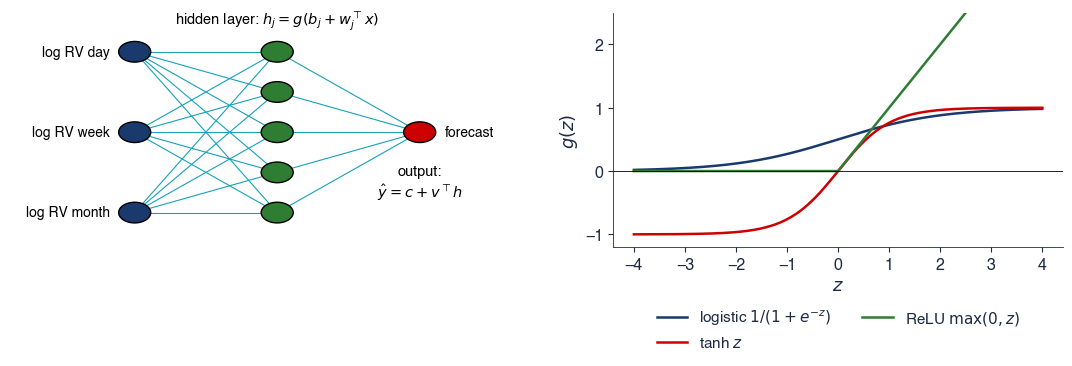

In [18]:
fig_mlp(save=False)

{'r2_mean': 0.0007947020729632825,
 'corr_rbf_garch': 0.4524962664343292,
 'corr_mlp_garch': 0.4260677328121187,
 'mean_rbf': 8.921138457736308,
 'mean_garch': 8.774517142809806,
 'max_rbf': 21.998340575872223,
 'max_garch': 37.27753107304393,
 'date_max_garch': '2016-06-28',
 'n': 4048,
 'first': '2010-01-07',
 'alpha': 0.07735279924593418,
 'beta': 0.8919594545557418,
 'neg_share': 0.0,
 'floor_share': 0.0}

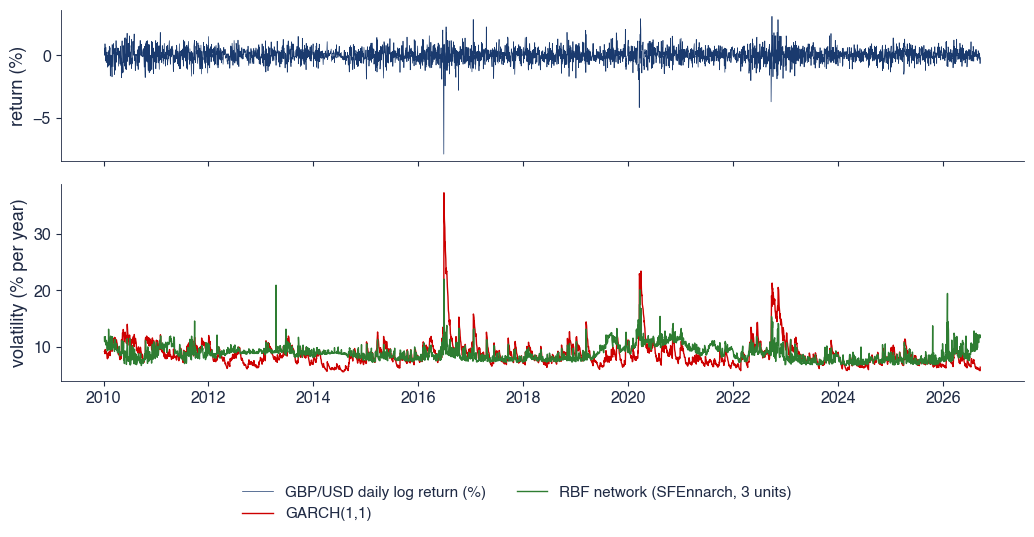

In [19]:
fig_nnarch(save=False)

{'rmse_tr': 2.642022237175943,
 'rmse_te': 27.56054651947837,
 'rmse_rw_tr': 0.6597908369782239,
 'rmse_rw_te': 0.8856900284224086,
 'max_tr': 134.87,
 'max_te': 163.855,
 'split': '2021-06-21',
 'first': '2000-01-03',
 'n': 6821,
 'r2_ret_te': -0.0014117754999840582}

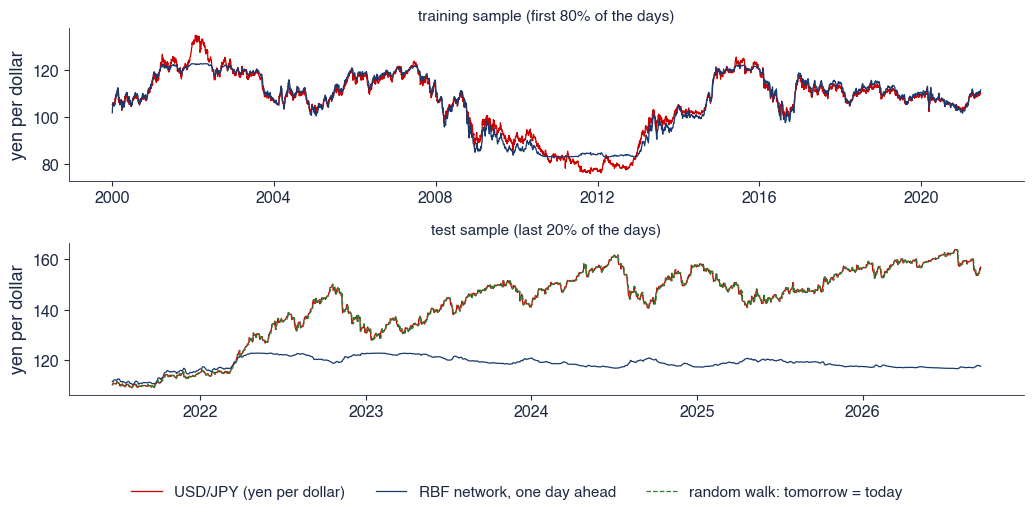

In [20]:
fig_nnjpy(save=False)

## 6. Forecasting realised volatility: HAR against machine learning

- Walk-forward with yearly refits; out-of-sample $R^2$, QLIKE and Diebold–Mariano tests; S&P 500 from 2013, Bitcoin from 2018.

In [21]:
def walk_forward(X, feats, make_model, oos_start, h=H, target='y'):
    """Yearly refits on an expanding window: for each test year, train on all earlier rows except the last h, whose
    targets overlap the test year (purging), then forecast every row of the year. Also returns the residual variance
    of the training fit (for the log-normal correction exp(yhat + s^2/2))."""
    test_years = sorted(set(X.index[X.index >= oos_start].year))
    pred, s2 = pd.Series(np.nan, index=X.index), pd.Series(np.nan, index=X.index)
    for yr in test_years:
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01']
        tr = tr.iloc[:-h] if h > 0 else tr
        m = make_model().fit(tr[feats], tr[target])
        pred[te] = m.predict(X.loc[te, feats])
        s2[te] = float(np.var(tr[target] - m.predict(tr[feats])))
    keep = X.index >= oos_start
    return pd.DataFrame({'pred': pred[keep], 's2': s2[keep]})


class MeanModel:
    """Benchmark: the mean of the training target."""

    def fit(self, X, y):
        self.m = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.m)


def rv_models(seed=SEED):
    """The five forecasting models of the realised variance (features, model factory)."""
    return {
        'Mean': (HAR, lambda: MeanModel()),
        'HAR': (HAR, lambda: LinearRegression()),
        'Lasso': (EXT, lambda: make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(5, gap=H), n_alphas=40))),
        'RF': (EXT, lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, max_features=0.5,
                                                  n_jobs=-1, random_state=seed)),
        'GB': (EXT, lambda: GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=3, subsample=0.8,
                                                      random_state=seed)),
        'MLP': (EXT, lambda: MLPEnsemble(seed=seed)),
    }


def qlike(rv, h):
    """QLIKE loss of Chapter 8: L = RV / h + ln h (lower is better)."""
    return rv / h + np.log(h)


def dm_test(d, lag=H):
    """Diebold-Mariano statistic for the mean of a loss difference d_t, with a Newey-West (Bartlett) long-run variance
    of `lag` lags; two-sided p-value from N(0, 1)."""
    d = np.asarray(d, float)
    n, u = len(d), d - d.mean()
    lrv = np.sum(u * u) / n
    for j in range(1, lag + 1):
        lrv += 2 * (1 - j / (lag + 1)) * np.sum(u[j:] * u[:-j]) / n
    t = d.mean() / np.sqrt(lrv / n)
    return float(t), float(2 * stats.norm.sf(abs(t)))


def rv_forecasts(k, models=None, h=H):
    """Walk-forward forecasts of all models for one series, with the variance forecast exp(yhat + s^2/2)."""
    X = rv_frame(k, h)
    models = models or rv_models()
    P = {}
    for name, (feats, make) in models.items():
        f = walk_forward(X, feats, make, OOS[k], h)
        f['var'] = np.exp(f['pred'] + f['s2'] / 2)
        P[name] = f
    return X, P


def rv_metrics(X, P, bench='HAR', h=H):
    """Out-of-sample R^2 against the training mean and against HAR (log RV), QLIKE, and the Diebold-Mariano test of
    equal QLIKE against HAR."""
    idx = P[bench].index
    y, rv = X.loc[idx, 'y'], X.loc[idx, 'rv']
    out = {}
    for name, f in P.items():
        L = qlike(rv, f['var'])
        Lb = qlike(rv, P[bench]['var'])
        t, p = dm_test(L - Lb, h) if name != bench else (np.nan, np.nan)
        out[name] = {'mse': float(np.mean((y - f['pred']) ** 2)), 'r2_mean': oos_r2(y, f['pred'], P['Mean']['pred']),
                     'r2_har': oos_r2(y, f['pred'], P[bench]['pred']), 'qlike': float(L.mean()), 'dm_t': t, 'dm_p': p}
    out['n'] = int(len(idx))
    out['first'] = idx[0].date().isoformat()
    out['last'] = idx[-1].date().isoformat()
    return out


def wf_design(k='sp500', h=H):
    """The walk-forward design of the volatility forecasts: one fold per test year, an expanding training window, the
    last h training rows purged (their targets reach into the test year)."""
    X = rv_frame(k, h)
    years = sorted(set(X.index[X.index >= OOS[k]].year))
    rows = []
    for yr in years:
        tr = X[X.index < f'{yr}-01-01']
        rows.append({'year': int(yr), 'n_train': int(len(tr) - h), 'n_test': int((X.index.year == yr).sum()),
                     'last_train': tr.index[-h - 1].date().isoformat(), 'first_purged': tr.index[-h].date().isoformat()})
    return {'n_folds': len(years), 'first': X.index[0].date().isoformat(), 'rows': rows, 'h': h}


def fig_rv_forecasts(X, P, k='sp500', periods=(('2020-01-01', '2020-12-31'), ('2025-01-01', '2025-09-18')), save=True):
    """Annualised weekly realised volatility and the HAR, random forest and MLP forecasts in two periods."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    a = 252
    for i, (s, e) in enumerate(periods):
        idx = P['HAR'].loc[s:e].index
        ax[i].plot(idx, np.sqrt(a * X.loc[idx, 'rv']), color='black', lw=1.4, label='realised, next 5 days')
        for name, ls in [('HAR', '-'), ('RF', '--'), ('MLP', ':')]:
            ax[i].plot(idx, np.sqrt(a * P[name].loc[idx, 'var']), color=MCOL[name], lw=1.4, ls=ls, label=f'{name} forecast')
        ax[i].set_title(f'{NAME[k]}, {s[:4]}', fontsize=11)
        ax[i].tick_params(axis='x', labelrotation=30)
    ax[0].set_ylabel('volatility (% per year)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_rv_forecasts')

In [22]:
wf_design()['rows'][:2]

[{'year': 2013,
  'n_train': 1188,
  'n_test': 252,
  'last_train': '2012-12-21',
  'first_purged': '2012-12-24'},
 {'year': 2014,
  'n_train': 1440,
  'n_test': 252,
  'last_train': '2013-12-23',
  'first_purged': '2013-12-24'}]

In [23]:
RV = {}
for k in ('sp500', 'btc'):
    X, P = rv_forecasts(k)
    RV[k] = (X, P)
    print(NAME[k])
    print(pd.DataFrame({m: v for m, v in rv_metrics(X, P).items() if isinstance(v, dict)}).T.round(4))

S&P 500
          mse  r2_mean  r2_har   qlike    dm_t    dm_p
Mean   1.1238   0.0000 -1.5956  0.8745  5.8675  0.0000
HAR    0.4330   0.6147  0.0000  0.4141     NaN     NaN
Lasso  0.4024   0.6419  0.0707  0.3998 -5.1223  0.0000
RF     0.4287   0.6185  0.0099  0.4158  0.3220  0.7475
GB     0.4445   0.6045 -0.0267  0.4206  1.0204  0.3076
MLP    0.3969   0.6468  0.0833  0.3976 -3.9628  0.0001


Bitcoin
          mse  r2_mean  r2_har   qlike    dm_t    dm_p
Mean   0.9905   0.0000 -0.7864  3.3350  7.4177  0.0000
HAR    0.5545   0.4402  0.0000  3.1115     NaN     NaN
Lasso  0.5435   0.4513  0.0198  3.1078 -0.6429  0.5203
RF     0.5608   0.4338 -0.0115  3.1193  0.8099  0.4180
GB     0.5779   0.4165 -0.0423  3.1478  2.1215  0.0339
MLP    0.5563   0.4384 -0.0033  3.1228  1.0976  0.2724


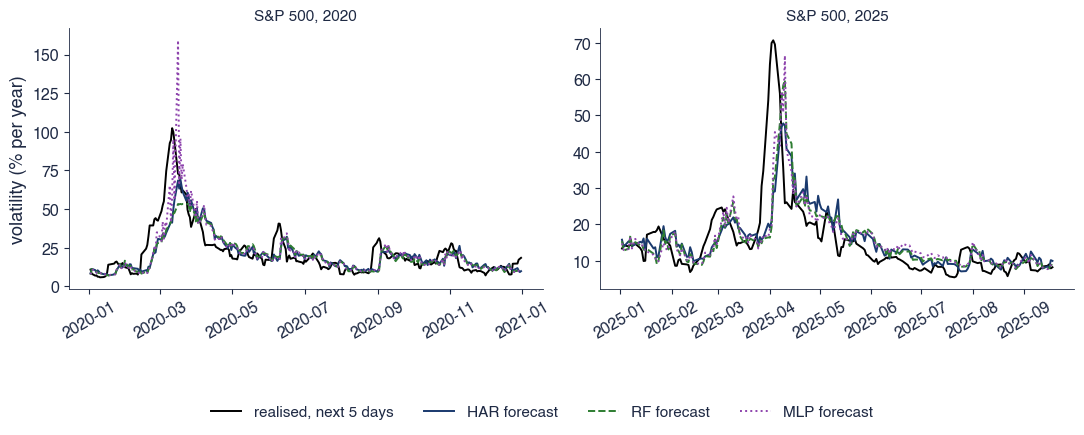

In [24]:
fig_rv_forecasts(*RV['sp500'], save=False)

## 7. Feature importance: permutation and exact Shapley values

In [25]:
def shapley_values(predict, X, B, feats):
    """Exact interventional Shapley values for a few features: phi_j(x) = sum over subsets S of the other features of
    |S|!(p-|S|-1)!/p! [v(S + j) - v(S)], with v(S) = the average prediction when the features in S take the values of x
    and the others the values of the background rows B."""
    from itertools import combinations
    from math import factorial
    p = len(feats)
    Xv, Bv = X[feats].values, B[feats].values
    cache = {}

    def v(S):
        if S not in cache:
            Z = np.repeat(Bv[None, :, :], len(Xv), axis=0)
            for j in S:
                Z[:, :, j] = Xv[:, j][:, None]
            cache[S] = predict(pd.DataFrame(Z.reshape(-1, p), columns=feats)).reshape(len(Xv), len(Bv)).mean(1)
        return cache[S]
    phi = np.zeros((len(Xv), p))
    for j in range(p):
        others = [i for i in range(p) if i != j]
        for s in range(p):
            for S in combinations(others, s):
                w = factorial(len(S)) * factorial(p - len(S) - 1) / factorial(p)
                phi[:, j] += w * (v(tuple(sorted(S + (j,)))) - v(tuple(sorted(S))))
    return pd.DataFrame(phi, columns=feats, index=X.index), float(v(tuple()).mean())


def importance(k='sp500', split='2019-12-31', n_bg=100, n_x=400, seed=SEED):
    """Permutation importance (2020-2026) of the random forest on the extended features (trained up to 2019, purged);
    exact Shapley values of a random forest on the three HAR features."""
    X = rv_frame(k)
    tr, te = X.loc[:split].iloc[:-H], X.loc[split:].iloc[1:]
    rf = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, max_features=0.5, n_jobs=-1,
                               random_state=seed).fit(tr[EXT], tr['y'])
    pi = permutation_importance(rf, te[EXT], te['y'], n_repeats=10, random_state=seed, scoring='neg_mean_squared_error')
    rf3 = RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, n_jobs=-1, random_state=seed)
    rf3.fit(tr[HAR], tr['y'])
    rng = np.random.default_rng(seed)
    B = tr.iloc[rng.choice(len(tr), n_bg, replace=False)]
    Xs = te.iloc[np.sort(rng.choice(len(te), min(n_x, len(te)), replace=False))]
    phi, base = shapley_values(rf3.predict, Xs, B, HAR)
    return {'perm': dict(zip(EXT, pi.importances_mean.tolist())), 'perm_sd': dict(zip(EXT, pi.importances_std.tolist())),
            'phi': phi, 'Xs': Xs, 'base': base, 'pred_check': float(np.max(np.abs(phi.sum(1) + base - rf3.predict(Xs[HAR])))),
            'mean_abs_phi': {f: float(phi[f].abs().mean()) for f in HAR}, 'n_test': int(len(te))}


def fig_importance(I=None, save=True):
    """Left: permutation importance (increase in test MSE); right: Shapley values of the three HAR features."""
    I = I or importance()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios': [1, 1.1]})
    order = sorted(EXT, key=lambda f: I['perm'][f])
    ax[0].barh([FEAT_LABEL[f] for f in order], [I['perm'][f] for f in order],
               xerr=[I['perm_sd'][f] for f in order], color=[FEAT_COL[f] for f in order], ecolor='black')
    ax[0].set_xlabel('increase in test MSE when the feature is shuffled')
    for f in HAR:
        ax[1].scatter(I['Xs'][f], I['phi'][f], s=9, color=FEAT_COL[f], alpha=0.7, label=FEAT_LABEL[f])
    ax[1].axhline(0, color='black', lw=0.6)
    ax[1].set_xlabel('feature value (log RV)')
    ax[1].set_ylabel('Shapley value (contribution to log RV)')
    st.legend_outside_bottom(ax[1], ncol=3, y=-0.2)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_importance')
    return {k: v for k, v in I.items() if k not in ('phi', 'Xs')}

{'perm': {'d': 0.033939073347199325,
  'w': 0.20092658379733824,
  'm': 0.053124259429146746,
  'd1': 0.007534248582712172,
  'd2': -0.001175927055575826,
  'd3': -0.001179044495814263,
  'd4': 0.0005270763381857501,
  'q': -0.003188247281670914,
  'r': 0.010060809061930964,
  'r_neg': 0.006115000952395011,
  'abs_r': 0.00021698844351578095},
 'perm_sd': {'d': 0.0040455165203227336,
  'w': 0.008747307052157044,
  'm': 0.004891805455742211,
  'd1': 0.001616334407508967,
  'd2': 0.0005815050882636543,
  'd3': 0.00016670581474578677,
  'd4': 0.00020021311979630572,
  'q': 0.0017523869947329426,
  'r': 0.0021145551220697386,
  'r_neg': 0.0016408604089434703,
  'abs_r': 0.00024125389565855213},
 'base': -0.8898675658746603,
 'pred_check': 1.3322676295501878e-15,
 'mean_abs_phi': {'d': 0.13044387667647223,
  'w': 0.5177782852527639,
  'm': 0.13071118443280855},
 'n_test': 1682}

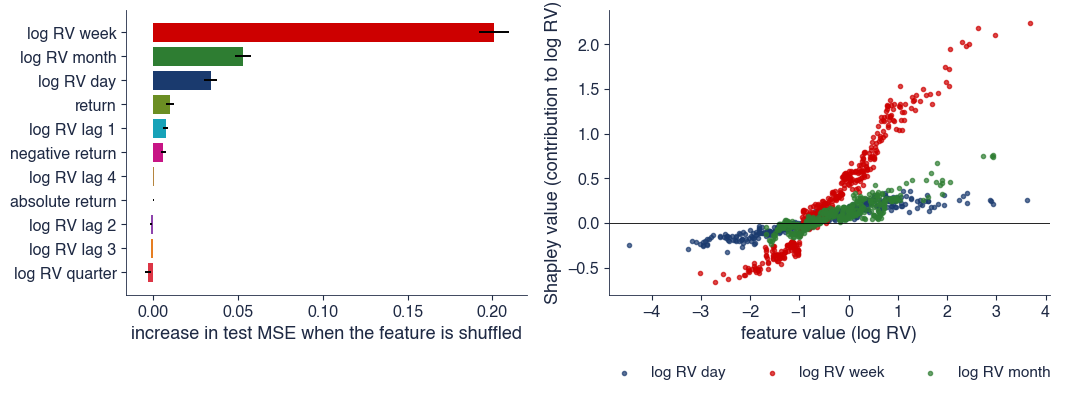

In [26]:
fig_importance(save=False)

## 8. The sign of tomorrow's return against the majority-class baseline

In [27]:
def sign_frame(k):
    """Features at the close of day t (the last five returns, sums over 5, 21 and 63 days, volatility over 21 and 63
    days) and the target 1{r_t+1 > 0}."""
    r = returns(k)
    X = pd.DataFrame({f'r{j}': r.shift(j) for j in range(5)})
    X['m5'], X['m21'], X['m63'] = r.rolling(5).sum(), r.rolling(21).sum(), r.rolling(63).sum()
    X['v21'], X['v63'] = r.rolling(21).std(), r.rolling(63).std()
    X['y'] = (r.shift(-1) > 0).astype(float)
    X['ret'] = r.shift(-1)
    return X.dropna()


def sign_models(seed=SEED):
    return {'Logit': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
            'RF': lambda: RandomForestClassifier(n_estimators=N_TREES, min_samples_leaf=100, max_features=0.5, n_jobs=-1,
                                                 random_state=seed),
            'GB': lambda: GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=2, subsample=0.8,
                                                     random_state=seed)}


def sign_walk_forward(k, models=None, oos_start=None):
    """Yearly walk-forward classification; the majority class of the training sample is the baseline forecast."""
    X = sign_frame(k)
    oos_start = oos_start or OOS_SIGN[k]
    models = models or sign_models()
    keep = X.index >= oos_start
    prob = {m: pd.Series(np.nan, index=X.index) for m in models}
    base = pd.Series(np.nan, index=X.index)
    for yr in sorted(set(X.index[keep].year)):
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01'].iloc[:-1]
        base[te] = float(tr['y'].mean() >= 0.5)
        for name, make in models.items():
            m = make().fit(tr[SIGN_FEATS], tr['y'].astype(int))
            prob[name][te] = m.predict_proba(X.loc[te, SIGN_FEATS])[:, 1]
    return X[keep], {m: p[keep] for m, p in prob.items()}, base[keep]


def sign_metrics(X, prob, base):
    """Accuracy of each model and of the baseline; z test of the accuracy against the baseline rate; AUC."""
    y = X['y'].values
    acc_b = float(np.mean(base.values == y))
    n = len(y)
    out = {'n': int(n), 'up': float(y.mean()), 'base_acc': acc_b, 'first': X.index[0].date().isoformat()}
    for name, p in prob.items():
        acc = float(np.mean((p.values >= 0.5) == y))
        z = (acc - acc_b) / np.sqrt(acc_b * (1 - acc_b) / n)
        out[name] = {'acc': acc, 'diff': acc - acc_b, 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z))),
                     'auc': float(roc_auc_score(y, p.values)), 'share_up_pred': float(np.mean(p.values >= 0.5))}
    return out


def fig_sign(S, save=True):
    """Accuracy minus the baseline accuracy (percentage points) with 95% bands, per asset and model."""
    keys = list(S)
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    xs = np.arange(len(keys))
    for i, m in enumerate(['Logit', 'RF', 'GB']):
        vals = [100 * S[k][m]['diff'] for k in keys]
        ax.bar(xs + (i - 1) * 0.26, vals, width=0.25, color=MCOL[m], label={'Logit': 'logit', 'RF': 'random forest',
                                                                           'GB': 'gradient boosting'}[m])
    for j, k in enumerate(keys):
        se = 100 * 1.96 * np.sqrt(S[k]['base_acc'] * (1 - S[k]['base_acc']) / S[k]['n'])
        ax.fill_between([j - 0.42, j + 0.42], -se, se, color=st.Teal, alpha=0.18, lw=0,
                        label='95% band under no skill' if j == 0 else None)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{NAME[k]}\n(baseline {100 * S[k]['base_acc']:.1f}%)" for k in keys])
    ax.set_ylabel('accuracy minus baseline (pp)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.3)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_sign')

In [28]:
SG = {k: sign_metrics(*sign_walk_forward(k)) for k in ('sp500', 'bet', 'btc')}
pd.DataFrame({(k, m): SG[k][m] for k in SG for m in ('Logit', 'RF', 'GB')}).T.round(4)

acc    diff       z       p     auc  share_up_pred
sp500 Logit  0.5379 -0.0062 -0.8489  0.3960  0.5111         0.8604
      RF     0.5311 -0.0130 -1.7856  0.0742  0.5068         0.7405
      GB     0.5209 -0.0232 -3.1906  0.0014  0.5057         0.7129
bet   Logit  0.5373 -0.0004 -0.0586  0.9533  0.5332         0.8988
      RF     0.5363 -0.0015 -0.2051  0.8375  0.5332         0.7697
      GB     0.5297 -0.0081 -1.1134  0.2655  0.5164         0.7892
btc   Logit  0.5107  0.0013  0.1418  0.8872  0.5147         0.8799
      RF     0.5006 -0.0088 -0.9929  0.3207  0.5190         0.7681
      GB     0.4997 -0.0097 -1.0993  0.2716  0.5126         0.6785

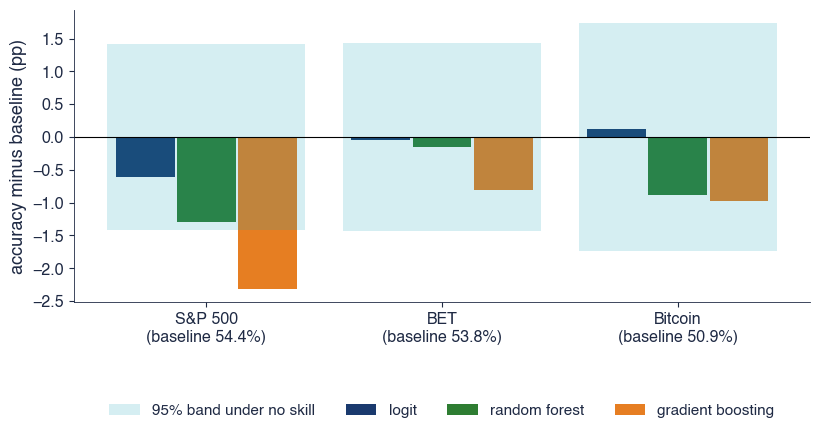

In [29]:
fig_sign(SG, save=False)

## 9. VaR 1% by quantile regression and quantile boosting

In [30]:
def qvar_frame(k):
    """Features at the close of day t: the square roots of the variance proxy over 1, 5 and 22 days (daily volatility
    in %) and the return r_t; target: the next log return r_t+1 (%)."""
    v, r = daily_variance(k)
    X = pd.DataFrame({'sd': np.sqrt(v), 'sw': np.sqrt(v.rolling(5).mean()), 'sm': np.sqrt(v.rolling(22).mean()), 'r': r})
    X['y'] = r.shift(-1)
    return X.dropna()


def quantile_models(a=ALPHA_VAR, seed=SEED):
    return {'QR': lambda: QuantileRegressor(quantile=a, alpha=0.0, solver='highs'),
            'QGB': lambda: GradientBoostingRegressor(loss='quantile', alpha=a, n_estimators=300, learning_rate=0.05,
                                                     max_depth=2, min_samples_leaf=50, subsample=0.8, random_state=seed)}


def garch_var(r, oos_start, a=ALPHA_VAR):
    """GARCH(1,1)-t VaR for the next day, re-estimated each January on all earlier returns (Chapter 10)."""
    out = pd.Series(np.nan, index=r.index)
    for yr in sorted(set(r.index[r.index >= oos_start].year)):
        first = r.index[r.index.year == yr][0]
        am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
        res = am.fit(last_obs=first, disp='off')
        f = res.forecast(start=first, horizon=1, reindex=False)
        nu = float(res.params['nu'])
        q = stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu)
        v = -(res.params['mu'] + np.sqrt(f.variance['h.1']) * q)
        idx = v.index[v.index.year == yr]
        out[idx] = v[idx]
    return out


def quantile_var(k, a=ALPHA_VAR, oos_start=None):
    """VaR 1% forecasts (positive losses) of four methods for the rows of the out-of-sample years."""
    X = qvar_frame(k)
    oos_start = oos_start or OOS[k]
    V = {}
    for name, make in quantile_models(a).items():
        f = walk_forward(X, QV_FEATS, make, oos_start, h=1)
        V[name] = -f['pred']
    keep = X.index >= oos_start
    hs = -X['r'].rolling(HS_WINDOW).quantile(a)
    V['HS'] = hs[keep]
    V['GARCH-t'] = garch_var(X['r'], oos_start, a)[keep]
    return X[keep], pd.DataFrame(V)


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec POF test: LR_uc and its chi-square(1) p-value."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = (n - x) * np.log(1 - ph) + (x * np.log(ph) if x > 0 else 0.0)
    lr = -2 * (l0 - l1)
    return float(lr), float(stats.chi2.sf(lr, 1))


def christoffersen(hits):
    """Christoffersen independence test: LR_ind and its chi-square(1) p-value, from the transition counts."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))
    p01, p11 = n01 / max(n00 + n01, 1), n11 / max(n10 + n11, 1)
    p = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    def ll(q, k0, k1):
        return (k0 * np.log(1 - q) if k0 else 0.0) + (k1 * np.log(q) if k1 else 0.0)
    lr = -2 * (ll(p, n00 + n10, n01 + n11) - ll(p01, n00, n01) - ll(p11, n10, n11))
    return float(lr), float(stats.chi2.sf(lr, 1)), int(n11)


def var_backtest(X, V, a=ALPHA_VAR):
    """Exceedances, Kupiec and Christoffersen p-values and the average quantile loss of each VaR forecast."""
    y = X['y']
    out = {'n': int(len(y)), 'first': X.index[0].date().isoformat()}
    for m in V:
        hit = (y < -V[m]).astype(int)
        x = int(hit.sum())
        lr, p = kupiec(x, len(y), a)
        lri, pi, n11 = christoffersen(hit)
        ql = float(np.mean((a - hit) * (y + V[m])))
        out[m] = {'x': x, 'rate': x / len(y), 'lr_uc': lr, 'p_uc': p, 'lr_ind': lri, 'p_ind': pi, 'n11': n11,
                  'qloss': ql, 'mean_var': float(V[m].mean()),
                  'x2020': int(hit.loc['2020'].sum()) if '2020' in hit.index.year.astype(str) else None}
    return out


def fig_qvar(X, V, k='sp500', periods=(('2020-01-01', '2020-12-31'), ('2025-01-01', '2025-09-18')), save=True):
    """Daily returns and minus VaR 1% of quantile regression, quantile boosting, historical simulation and GARCH-t."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    for i, (s, e) in enumerate(periods):
        Xs, Vs = X.loc[s:e], V.loc[s:e]
        ax[i].bar(Xs.index, Xs['y'], width=1.0, color=st.Teal, label='next-day log return (%)')
        for m, ls in [('QR', '-'), ('QGB', '-'), ('HS', '--'), ('GARCH-t', ':')]:
            ax[i].plot(Vs.index, -Vs[m], color=MCOL[m], lw=1.3, ls=ls, label=f'minus VaR 1%, {m}')
        hit = Xs['y'] < -Vs['QR']
        ax[i].scatter(Xs.index[hit], Xs['y'][hit], color=st.IDAred, s=22, zorder=3, label='exceedance of QR VaR')
        ax[i].set_title(f'{NAME[k]}, {s[:4]}', fontsize=11)
        ax[i].tick_params(axis='x', labelrotation=30)
    ax[0].set_ylabel('return (%)')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_qvar')

In [31]:
QV = {}
for k in ('sp500', 'btc'):
    X, Vf = quantile_var(k)
    QV[k] = (X, Vf)
    B = var_backtest(X, Vf)
    print(NAME[k])
    print(pd.DataFrame({m: B[m] for m in ('QR', 'QGB', 'HS', 'GARCH-t')}).T.round(4))

S&P 500
            x    rate   lr_uc    p_uc   lr_ind   p_ind  n11   qloss  mean_var  \
QR       28.0  0.0081  1.3145  0.2516   5.3830  0.0203  2.0  0.0338    2.7020   
QGB      42.0  0.0122  1.5490  0.2133   5.9412  0.0148  3.0  0.0351    2.4633   
HS       46.0  0.0133  3.5190  0.0607  17.9254  0.0000  6.0  0.0478    2.9668   
GARCH-t  52.0  0.0151  7.7800  0.0053   7.0170  0.0081  4.0  0.0350    2.4204   

         x2020  
QR         4.0  
QGB        7.0  
HS        10.0  
GARCH-t    8.0  


Bitcoin
            x    rate   lr_uc    p_uc  lr_ind   p_ind  n11   qloss  mean_var  \
QR       23.0  0.0072  2.7330  0.0983  0.3350  0.5627  0.0  0.1303   10.4635   
QGB      47.0  0.0148  6.3782  0.0116  1.4098  0.2351  0.0  0.1319    8.8581   
HS       32.0  0.0101  0.0010  0.9744  0.9402  0.3322  1.0  0.1301    9.2971   
GARCH-t  41.0  0.0129  2.4519  0.1174  0.3436  0.5577  1.0  0.1315    8.5172   

         x2020  
QR         1.0  
QGB        5.0  
HS         2.0  
GARCH-t    4.0  


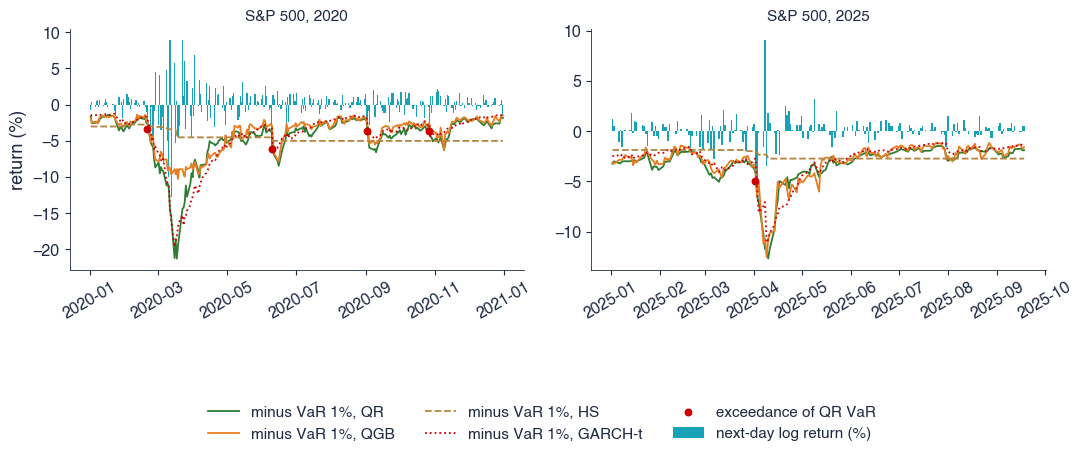

In [32]:
fig_qvar(*QV['sp500'], save=False)

## 10. Data snooping and the deflated Sharpe ratio

In [33]:
def expected_max_sr(N, sd):
    """Expected maximum of N independent N(0, sd^2) Sharpe ratios (Bailey and Lopez de Prado, 2014):
    sd [(1 - g) Phi^-1(1 - 1/N) + g Phi^-1(1 - 1/(N e))], g = Euler-Mascheroni constant."""
    if N == 1:
        return 0.0
    return float(sd * ((1 - EULER) * stats.norm.ppf(1 - 1 / N) + EULER * stats.norm.ppf(1 - 1 / (N * np.e))))


def max_sharpe_sim(Ns=(1, 2, 5, 10, 20, 50, 100, 200, 500, 1000), years=10, n_sim=2000, seed=SEED):
    """The annualised Sharpe ratio of a strategy without skill is about N(0, 1/years); the best of N such strategies."""
    rng = np.random.default_rng(seed)
    sd = 1 / np.sqrt(years)
    Z = rng.normal(0, sd, (n_sim, max(Ns)))
    out = {}
    for N in Ns:
        m = Z[:, :N].max(1)
        out[int(N)] = {'mean': float(m.mean()), 'q05': float(np.quantile(m, 0.05)), 'q95': float(np.quantile(m, 0.95)),
                       'formula': expected_max_sr(N, sd)}
    return out


def ma_rules():
    """Moving-average rules: (short, long) crossovers and price above a moving average (short = 1)."""
    rules = [(s, l) for s in (5, 10, 20, 30, 50) for l in (50, 100, 150, 200, 250) if s < l]
    return rules + [(1, l) for l in (20, 50, 100, 150, 200, 250)]


def rule_returns(P, s, l):
    """Daily simple returns (%) of a long-or-cash rule: invested on day t+1 if MA_s(t) > MA_l(t), else in cash (0)."""
    R = 100 * P.pct_change()
    sig = (P.rolling(s).mean() > P.rolling(l).mean()).astype(float)
    return (sig.shift(1) * R).dropna()


def sharpe(x, a=252):
    """Annualised Sharpe ratio of daily returns (no risk-free rate)."""
    return float(np.sqrt(a) * x.mean() / x.std(ddof=1))


def deflated_sharpe(sr, sr_all, T, skew, kurt):
    """Deflated Sharpe ratio (Bailey and Lopez de Prado, 2014), per-period Sharpe ratios:
    DSR = Phi[(SR - SR_0) sqrt(T - 1) / sqrt(1 - g3 SR + (g4 - 1)/4 SR^2)], SR_0 = expected maximum of N trials."""
    sr0 = expected_max_sr(len(sr_all), float(np.std(sr_all, ddof=1)))
    z = (sr - sr0) * np.sqrt(T - 1) / np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    psr = (sr - 0) * np.sqrt(T - 1) / np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return {'sr0': float(sr0), 'dsr': float(stats.norm.cdf(z)), 'psr': float(stats.norm.cdf(psr)), 'z': float(z)}


def snooping(k='sp500', split='2014-12-31'):
    """The MA rules on the S&P 500: in-sample (2000-2014) and out-of-sample (2015-2026) Sharpe ratios; the deflated
    Sharpe ratio of the best in-sample rule."""
    P = np.exp(returns(k).cumsum() / 100)
    rows = []
    for s, l in ma_rules():
        x = rule_returns(P, s, l)
        rows.append({'s': s, 'l': l, 'is': sharpe(x.loc[:split]), 'oos': sharpe(x.loc[split:].iloc[1:]),
                     'is_pp': float(x.loc[:split].mean() / x.loc[:split].std(ddof=1))})
    D = pd.DataFrame(rows)
    b = D['is'].idxmax()
    best = rule_returns(P, int(D.loc[b, 's']), int(D.loc[b, 'l'])).loc[:split]
    bh = 100 * P.pct_change().dropna()
    ds = deflated_sharpe(float(D.loc[b, 'is_pp']), D['is_pp'].values, len(best), float(stats.skew(best)),
                         float(stats.kurtosis(best, fisher=False)))
    return {'D': D, 'N': int(len(D)), 'best': {'s': int(D.loc[b, 's']), 'l': int(D.loc[b, 'l']), 'is': float(D.loc[b, 'is']),
                                               'oos': float(D.loc[b, 'oos']), 'is_pp': float(D.loc[b, 'is_pp']),
                                               'T': int(len(best)), 'skew': float(stats.skew(best)),
                                               'kurt': float(stats.kurtosis(best, fisher=False))},
            'sd_pp': float(D['is_pp'].std(ddof=1)), 'dsr': ds, 'bh_is': sharpe(bh.loc[:split]),
            'bh_oos': sharpe(bh.loc[split:].iloc[1:]), 'median_is': float(D['is'].median()),
            'median_oos': float(D['oos'].median()), 'corr': float(D['is'].corr(D['oos'])),
            'rank_oos': int((D['oos'] > D.loc[b, 'oos']).sum() + 1)}


def fig_snooping(M=None, S=None, save=True):
    """Left: the best of N strategies without skill (10 years); right: in-sample against out-of-sample Sharpe ratios of
    the MA rules on the S&P 500."""
    M = M or max_sharpe_sim()
    S = S or snooping()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    Ns = sorted(M)
    ax[0].fill_between(Ns, [M[n]['q05'] for n in Ns], [M[n]['q95'] for n in Ns], color=st.Teal, alpha=0.25,
                       label='5%-95% of the best Sharpe ratio')
    ax[0].plot(Ns, [M[n]['mean'] for n in Ns], color=st.IDAred, marker='o', label='average best Sharpe ratio (simulation)')
    ax[0].plot(Ns, [M[n]['formula'] for n in Ns], color='black', ls='--', label='expected maximum (formula)')
    ax[0].set_xscale('log')
    ax[0].set_xlabel('number of strategies tried, N')
    ax[0].set_ylabel('annualised Sharpe ratio')
    D = S['D']
    ax[1].scatter(D['is'], D['oos'], color=st.MainBlue, s=26, label='moving-average rule')
    b = S['best']
    ax[1].scatter([b['is']], [b['oos']], color=st.IDAred, s=70, marker='*', zorder=3, label='best rule in sample')
    ax[1].scatter([S['bh_is']], [S['bh_oos']], color=st.Forest, s=50, marker='s', zorder=3, label='buy and hold')
    ax[1].set_xlabel('Sharpe ratio, 2000-2014 (in sample)')
    ax[1].set_ylabel('Sharpe ratio, 2015-2026')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_snooping')
    return M, S

{'N': 30,
 'best': {'s': 50,
  'l': 200,
  'is': 0.6600754003321481,
  'oos': 0.5435637072588214,
  'is_pp': 0.0415808418054825,
  'T': 3769,
  'skew': -0.44129492402298015,
  'kurt': 11.993934591603852},
 'sd_pp': 0.010544356060484162,
 'dsr': {'sr0': 0.021862586748086558,
  'dsr': 0.8842771186960274,
  'psr': 0.9941890089547538,
  'z': 1.1966429233878817},
 'bh_is': 0.22864581816555887,
 'bh_oos': 0.7249089397654159,
 'median_is': 0.4778107441989492,
 'median_oos': 0.5974477276299737,
 'corr': 0.039223983320922334,
 'rank_oos': 22}

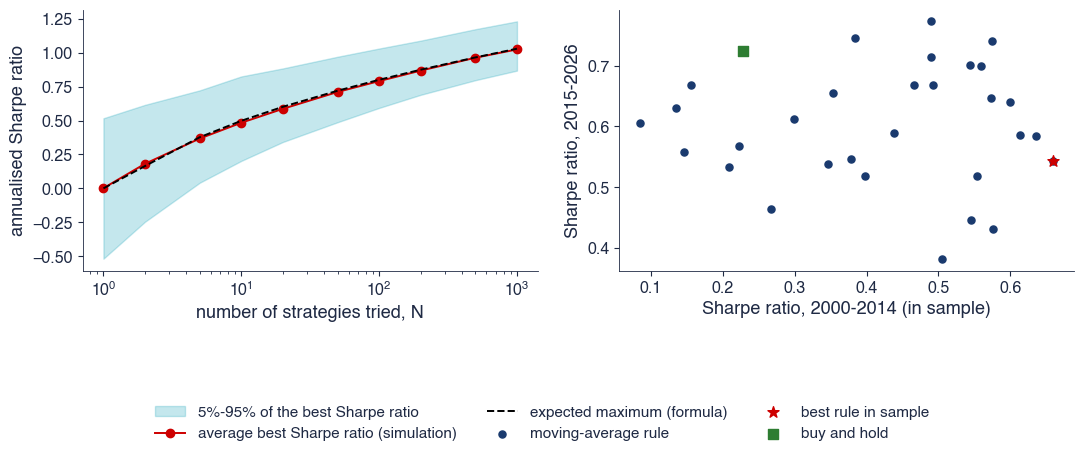

In [34]:
M, SN = fig_snooping(save=False)
{k: v for k, v in SN.items() if k != 'D'}

## 11. Case study: Gu, Kelly and Xiu (2020), published results

In [35]:
def fig_gkx(save=True):
    """Published results of Gu, Kelly and Xiu (2020): monthly out-of-sample R^2 (Table 1) and the Sharpe ratio of the
    value-weighted long-short decile portfolio (Table 7)."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    xs = np.arange(len(GKX_MODELS))
    col = [st.MainBlue] * 5 + [st.Forest] * 2 + [st.IDAred] * 5
    ax[0].bar(xs - 0.2, GKX_R2, width=0.4, color=col, label='all stocks')
    ax[0].bar(xs + 0.2, GKX_R2_TOP, width=0.4, facecolor='none', edgecolor=col, hatch='///', lw=1.0)
    ax[0].axhline(0, color='black', lw=0.6)
    ax[0].set_ylabel('monthly out-of-sample $R^2$ (%)')
    ax[1].bar(xs, GKX_SR, color=col)
    ax[1].set_ylabel('annualised Sharpe ratio, H-L decile')
    for a in ax:
        a.set_xticks(xs)
        a.set_xticklabels(GKX_MODELS, rotation=60, fontsize=9.5)
    handles = [Rectangle((0, 0), 1, 1, facecolor=c) for c in (st.MainBlue, st.Forest, st.IDAred)]
    handles += [Rectangle((0, 0), 1, 1, facecolor=st.MainBlue),
                Rectangle((0, 0), 1, 1, facecolor='none', edgecolor=st.MainBlue, hatch='///')]
    fig.legend(handles, ['linear and penalised', 'trees', 'neural networks', 'left: all stocks',
                         'left: top 1,000 stocks'], loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=5, frameon=False)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch13_gkx')

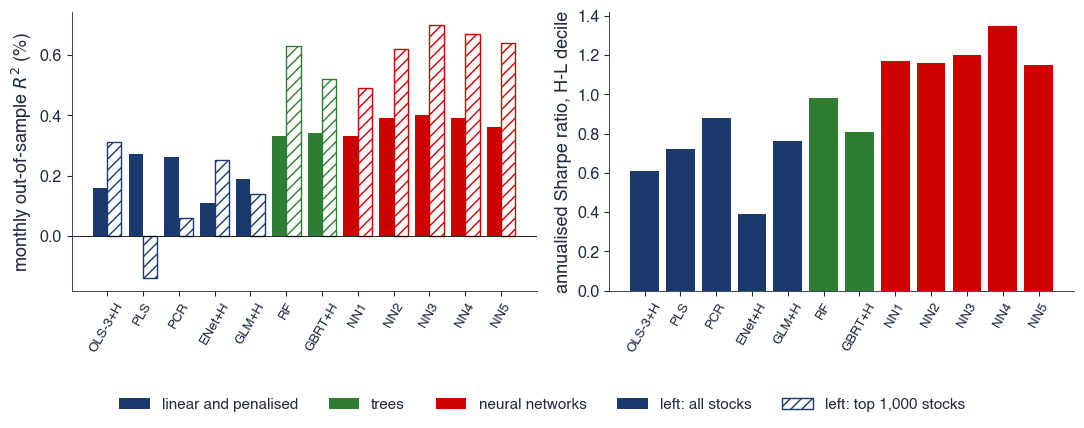

In [36]:
fig_gkx(save=False)

## 12. AI for scientific discovery: machine learning for BVB volatility

- Open question: do machine-learning volatility forecasts help on the Bucharest Stock Exchange?
- Starter result: the weekly variance of the BET from squared returns, HAR against a random forest (no high and low prices for the BET in the course data).
- Check before trusting any answer, yours or an AI's: time order, purging, scaling inside the training window, the S&P 500 features from the previous New York close, a benchmark and a test in every table.

In [37]:
b = returns('bet', '2008-01-01')
v = (b ** 2).clip(lower=0.01 * float((b ** 2).median()))
X = pd.DataFrame({'d': np.log(v), 'w': np.log(v.rolling(5).mean()), 'm': np.log(v.rolling(22).mean())})
fut = sum(v.shift(-j) for j in range(1, 6)) / 5
X['rv'], X['y'] = fut, np.log(fut)
X = X.dropna()
models = {'Mean': (HAR, lambda: MeanModel()), 'HAR': (HAR, lambda: LinearRegression()),
          'RF': (HAR, lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, n_jobs=-1, random_state=SEED))}
P = {}
for m, (f, make) in models.items():
    p = walk_forward(X, f, make, '2012-01-01')
    p['var'] = np.exp(p['pred'] + p['s2'] / 2)
    P[m] = p
pd.DataFrame({m: v for m, v in rv_metrics(X, P).items() if isinstance(v, dict)}).T.round(4)

,mse,r2_mean,r2_har,qlike,dm_t,dm_p
Mean,1.8230,0.0000,-0.6870,1.2565,8.2694,0.0000
HAR,1.0806,0.4072,0.0000,0.7819,NaN,NaN
RF,1.1305,0.3798,-0.0462,0.7957,1.0814,0.2795
